Nom : Khadijetou Mohamed abe

Filière : GLCC

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# 1.CODE SCRATCH

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap # Pour personnaliser nos couleurs exactement comme l'image

# 1.CODE SCRATCH

def distance_euclidienne(A, B):
    # """
    # Calcule la distance euclidienne entre deux points A et B.
    # Formule : √((x2 - x1)² + (y2 - y1)²)
    # """
    # initialisation de la somme des carrés à 0
    s = 0 
    # on parcourt chaque dimension (coordonnée x, y) des points
    for i in range(len(A)): 
        # on calcule la différence, on la met au carré et on l'ajoute à la somme
        s = s + (B[i] - A[i])**2 
    # on retourne la racine carrée (puissance 0.5)
    return s**0.5 

def obtenir_voisins(Data, x, k):
    # """
    # Calcule la distance entre le point 'x' et tous les points de 'Data',
    # puis retourne les 'k' points les plus proches.
    # """
    # initialisation d'une liste vide
    distances = [] 
    
    # on parcourt chaque point dans notre base
    for point in Data: 
        # les coordonnées sont tout sauf le dernier élément
        caracteristiques = point[:-1] 
        # le dernier élément est la classe Y du point
        label = point[-1] 
        # on calcule la distance
        dist = distance_euclidienne(caracteristiques, x) 
        # on stocke le couple (distance, classe)
        distances.append((dist, label)) 
    
    # on trie la liste par ordre croissant selon la distance (index 0 du tuple)
    distances.sort(key=lambda element: element[0]) 
    
    # on garde uniquement les 'k' premiers (les plus proches)
    k_plus_proches = distances[:k] 
    return k_plus_proches

def classe_majoritaire(KLT, nbr_classes):
    # """
    # Compte les occurrences de chaque classe parmi les voisins (vote).
    # """
    # initialisation du tableau de comptage des classes à zéro
    LC = [0] * nbr_classes 
    
    # on parcourt nos k voisins
    for x in KLT: 
        # on récupère la classe Y du voisin en tant qu'entier
        i = int(x[1]) 
        # on incrémente le compteur de cette classe spécifique
        LC[i] = LC[i] + 1 
        
    # on cherche le maximum
    imax = 0 
    for i in range(nbr_classes): 
        # si cette classe a plus de votes que le maximum actuel
        if LC[i] > LC[imax]: 
            # elle devient la nouvelle classe majoritaire
            imax = i 
            
    # on retourne la classe gagnante
    return imax

def KNN_scratch(Data, x, k, nbr_classes):
    # on récupère les voisins
    voisins = obtenir_voisins(Data, x, k)
    # on retourne la classe gagnante
    return classe_majoritaire(voisins, nbr_classes)

## a. DATASET

In [34]:
# a. DATASET

# On fixe la graine pour avoir toujours les mêmes nuages de points
np.random.seed(42)

# Pour faire des nuages ronds comme sur votre image, on utilise 'np.random.normal'
# loc = centre du nuage [axe_x, axe_y], scale = dispersion (écart-type), size = nombre de points
# Classe 0 (Violet sur l'image) : Nuage à gauche
X0 = np.random.normal(loc=[20, 50], scale=8, size=(80, 2))
# Y0 contient des 0 (la cible/label)
Y0 = np.zeros((80, 1))

# Classe 1 (Vert sur l'image) : Nuage en haut à droite
X1 = np.random.normal(loc=[60, 70], scale=8, size=(80, 2))
# Y1 contient des 1
Y1 = np.ones((80, 1))

# Classe 2 (Rouge sur l'image) : Nuage en bas à droite
X2 = np.random.normal(loc=[60, 25], scale=8, size=(80, 2))
# Y2 contient des 2
Y2 = np.full((80, 1), 2)

# On regroupe toutes les caractéristiques X dans une seule matrice
X_data_knn = np.vstack((X0, X1, X2))
# On regroupe toutes les étiquettes Y dans un seul vecteur cible
y_data_knn = np.vstack((Y0, Y1, Y2))

# Préparation pour le code Scratch : format [x1, x2, Y]
Data_scratch = []
for i in range(len(X_data_knn)):
    # Ici on voit bien que le point intègre ses coordonnées ET sa classe Y
    point = [X_data_knn[i][0], X_data_knn[i][1], y_data_knn[i][0]]
    Data_scratch.append(point)

# Le point inconnu que l'on veut classifier (choisi au milieu pour voir qui gagne)
point_a_classifier = [45, 50]

## b. Exécution du code scratch

In [35]:
# b. Exécution du code scratch

# paramètre K (nombre de voisins)
k_voisins = 5
# nombre de classes possibles (0, 1, 2)
nb_classes_total = 3

# exécution de notre algorithme manuel
prediction_scratch = KNN_scratch(Data_scratch, point_a_classifier, k_voisins, nb_classes_total)

print(f"Classe prédite par notre code scratch pour le point {point_a_classifier} :")
print(prediction_scratch)

Classe prédite par notre code scratch pour le point [45, 50] :
0


## c. Code sklearn

In [44]:
# c. Code sklearn

# import de la classe KNeighborsClassifier depuis la bibliothèque sklearn
from sklearn.neighbors import KNeighborsClassifier

# On crée un objet modèle en spécifiant le nombre de voisins (n_neighbors = k)
modele_sklearn_knn = KNeighborsClassifier(n_neighbors=5)

# On entraîne le modèle sur nos données (l'apprentissage en KNN consiste juste à mémoriser les points)
# .ravel() est utilisé pour aplatir le tableau y en une seule dimension (requis par sklearn)
modele_sklearn_knn.fit(X_data_knn, y_data_knn.ravel())

# On demande au modèle de prédire la classe de notre point inconnu
# sklearn attend un tableau 2D, donc on met notre point entre doubles crochets [[ ]]
# on ajoute [0] à la fin pour extraire la valeur du résultat du tableau renvoyé
prediction_sklearn = modele_sklearn_knn.predict([point_a_classifier])[0]

## d. Comparaison et graphiques (scratch/sklearn)

Comparaison des prédictions :
Scratch : Classe 0 | Sklearn : Classe 0


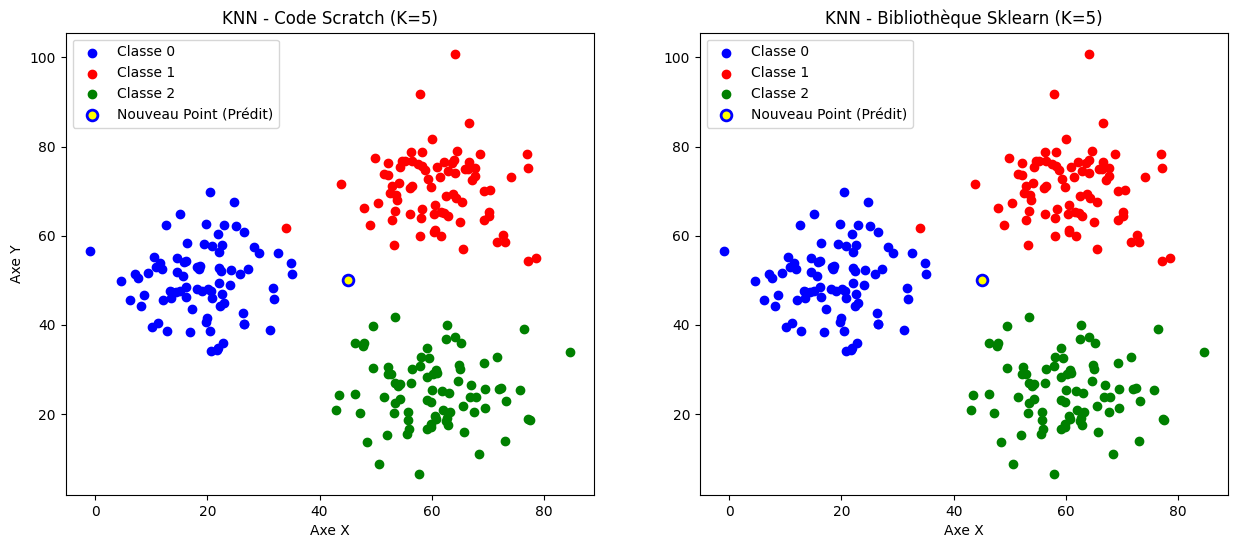

In [45]:
# d. Comparaison et graphiques (scratch/sklearn)

print("Comparaison des prédictions :")
print(f"Scratch : Classe {prediction_scratch} | Sklearn : Classe {int(prediction_sklearn)}")

# Création de la figure pour afficher les graphiques
# figsize (largeur, hauteur)
plt.figure(figsize=(15, 6))

# ---- Graphique Scratch ----
# 1 ligne, 2 colonnes, graphique numéro 1
plt.subplot(1, 2, 1)
# On trace les points de la classe 0 en bleu
plt.scatter(X0[:, 0], X0[:, 1], color='blue', label='Classe 0')
# On trace les points de la classe 1 en rouge
plt.scatter(X1[:, 0], X1[:, 1], color='red', label='Classe 1')
# On trace les points de la classe 2 en vert
plt.scatter(X2[:, 0], X2[:, 1], color='green', label='Classe 2')

# Définition de la couleur du point selon la prédiction scratch
couleur_pred_scratch = 'blue' if prediction_scratch == 0 else ('red' if prediction_scratch == 1 else 'green')
# On trace le point à classifier (une grande étoile jaune avec un bord de la couleur prédite)
plt.scatter(point_a_classifier[0], point_a_classifier[1], color='yellow', edgecolor=couleur_pred_scratch, marker='o', s=60, linewidth=2, label='Nouveau Point (Prédit)')

# Ajout des titres et légendes
plt.title('KNN - Code Scratch (K=5)')
plt.xlabel('Axe X')
plt.ylabel('Axe Y')
plt.legend()


# ---- Graphique Sklearn ----
# 1 ligne, 2 colonnes, graphique numéro 2
plt.subplot(1, 2, 2)
# On re-trace les mêmes points
plt.scatter(X0[:, 0], X0[:, 1], color='blue', label='Classe 0')
plt.scatter(X1[:, 0], X1[:, 1], color='red', label='Classe 1')
plt.scatter(X2[:, 0], X2[:, 1], color='green', label='Classe 2')

# Définition de la couleur selon la prédiction sklearn
couleur_pred_sklearn = 'blue' if prediction_sklearn == 0 else ('red' if prediction_sklearn == 1 else 'green')
# On trace le point à classifier avec la prédiction de Sklearn
plt.scatter(point_a_classifier[0], point_a_classifier[1], color='yellow', edgecolor=couleur_pred_sklearn, marker='o', s=60, linewidth=2, label='Nouveau Point (Prédit)')

# Ajout des titres et légendes
plt.title('KNN - Bibliothèque Sklearn (K=5)')
plt.xlabel('Axe X')
plt.legend()

# Affichage des deux graphiques
plt.show()